## Import thư viện

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from IPython.display import display, HTML

# Đọc dữ liệu từ file Excel

In [35]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from datetime import datetime

def hien_thi_tieu_de(text):
    display(HTML(f"<h2 style='color:blue'>{text}</h2>"))

def sua_diem_bi_doc_thanh_ngay(x):
    if isinstance(x, datetime):
        return float(f"{x.day}.{x.month}")
    return x

hien_thi_tieu_de("Đọc dữ liệu từ file Excel")

file_path = "diem_lop.xlsx"

df_raw = pd.read_excel(
    file_path,
    header=None,
    engine="openpyxl"
)

# Sửa dữ liệu bị đọc thành ngày
for col in df_raw.columns:
    df_raw[col] = df_raw[col].apply(sua_diem_bi_doc_thanh_ngay)

print("Kích thước dữ liệu:", df_raw.shape)

display(df_raw.head(10))

Kích thước dữ liệu: (56, 74)


,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,TỔNG HỢP ĐIỂM\n(Từ kỳ 1 năm nhất - hết kỳ 2 nă...,NaN,STT,1,2,3,4,5,6,7,...,62,63,64,65,66,67,68,69,70,71
1,NaN,NaN,MSSV,K225480106002,K225480106095,K225510201001,K225480106082,K225480106001,K225480106100,K225480106008,...,K225480106062,K225480106064,K225480106065,K225480106069,K225480106070,K225480106067,K225480106068,K225480106075,K225480106074,K225480106073
2,NaN,NaN,Tên Sinh Viên,Nguyễn Tuấn Anh,Nguyễn Tuấn Anh,Bùi Ngọc Anh,Vũ Việt Anh,Lê Tuấn Anh,Lý Văn Cường,Nguyễn Khánh Duy,...,Nguyễn Văn Thứ,Hoàng Thị Xuân Trang,Lê Quốc Trung,Lê Ngọc Tú,Nguyễn Đức Anh Tú,Nguyễn Đình Tú,Vũ Đức Tú,Nguyễn Đức Việt,Nguyễn Hoàng Việt,Lương Hoàng Việt
3,STT,Mã Môn học,Tên Môn học,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,TEE0432,Kỹ thuật lập trình nâng cao,2.5,3,3.0,3,3,3,3,...,3.7,3,3,NaN,3,3,3,3,3,3.7
5,2,TEE0591,Trí tuệ nhân tạo và học máy,3.5,2,2.5,3,3,3,3.7,...,3.5,3.5,3,NaN,3,3.5,3,3,3.7,3.7
6,3,TEE321,Xử lý ảnh,1.0,1,3.0,2.5,2,3.5,1,...,3,3,1,NaN,3,3,1,3,3,3.5
7,4,WSH442,Thực tập chuyên ngành Công nghệ phần mềm,3.0,3,2.0,NaN,3,4,3,...,3.5,3,1,NaN,2.5,3.5,4,2,3.7,3.7
8,5,TEE0480,Công nghệ phần mềm,3.5,NaN,2.5,3,3,3.5,NaN,...,3,3.5,1,NaN,3,3,3,3,3,3
9,6,TEE0497,Quản lý dự án công nghệ thông tin,3.5,3,3.0,3.5,3.5,3.7,3,...,3.7,3,3.5,NaN,3.5,3.5,3.5,3,3.5,3.7


# Lấy bảng điểm học phần

In [27]:
mssv_row = df_raw[
    df_raw.apply(lambda row: row.astype(str).str.contains("MSSV", na=False).any(), axis=1)
].index[0]

name_row = df_raw[
    df_raw.apply(lambda row: row.astype(str).str.contains("Tên Sinh Viên", na=False).any(), axis=1)
].index[0]

mssv_series = df_raw.iloc[mssv_row, :]

student_cols = [
    col for col in df_raw.columns
    if str(mssv_series[col]).startswith("K")
]

students = pd.DataFrame({
    "MSSV": [df_raw.iloc[mssv_row, col] for col in student_cols],
    "Họ tên": [df_raw.iloc[name_row, col] for col in student_cols]
})

In [28]:
hien_thi_tieu_de("Lấy bảng điểm học phần")

score_data = df_raw.iloc[name_row + 1:, :]

scores = score_data[student_cols].copy()

scores.columns = students["MSSV"].values

display(scores.head())

,K225480106002,K225480106095,K225510201001,K225480106082,K225480106001,K225480106100,K225480106008,K225480106007,K225480106093,K225480106003,...,K225480106062,K225480106064,K225480106065,K225480106069,K225480106070,K225480106067,K225480106068,K225480106075,K225480106074,K225480106073
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.5,3,3.0,3,3,3,3,3,3,2.5,...,3.7,3,3,NaN,3,3,3,3,3,3.7
5,3.5,2,2.5,3,3,3,3.7,4,4,3,...,3.5,3.5,3,NaN,3,3.5,3,3,3.7,3.7
6,1.0,1,3.0,2.5,2,3.5,1,3.5,3,3.7,...,3,3,1,NaN,3,3,1,3,3,3.5
7,3.0,3,2.0,NaN,3,4,3,3,3,3.5,...,3.5,3,1,NaN,2.5,3.5,4,2,3.7,3.7


# Làm sạch dữ liệu điểm

In [29]:
hien_thi_tieu_de("Làm sạch dữ liệu điểm")

scores = scores.replace(["x", "X", "—", "-", " ", "", "nan", "NaN"], np.nan)

scores = scores.apply(pd.to_numeric, errors="coerce")

scores = scores.where((scores >= 0) & (scores <= 4), np.nan)

display(scores.head())

,K225480106002,K225480106095,K225510201001,K225480106082,K225480106001,K225480106100,K225480106008,K225480106007,K225480106093,K225480106003,...,K225480106062,K225480106064,K225480106065,K225480106069,K225480106070,K225480106067,K225480106068,K225480106075,K225480106074,K225480106073
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.5,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.5,...,3.7,3.0,3.0,NaN,3.0,3.0,3.0,3.0,3.0,3.7
5,3.5,2.0,2.5,3.0,3.0,3.0,3.7,4.0,4.0,3.0,...,3.5,3.5,3.0,NaN,3.0,3.5,3.0,3.0,3.7,3.7
6,1.0,1.0,3.0,2.5,2.0,3.5,1.0,3.5,3.0,3.7,...,3.0,3.0,1.0,NaN,3.0,3.0,1.0,3.0,3.0,3.5
7,3.0,3.0,2.0,NaN,3.0,4.0,3.0,3.0,3.0,3.5,...,3.5,3.0,1.0,NaN,2.5,3.5,4.0,2.0,3.7,3.7


# Tính điểm trung bình từng sinh viên

In [30]:
hien_thi_tieu_de(" Tính điểm trung bình từng sinh viên")

students["Điểm TB"] = scores.mean(axis=0).values
students["Số môn có điểm"] = scores.count(axis=0).values

students["Có điểm F"] = scores.apply(
    lambda col: (col < 1.0).any(),
    axis=0
).values

display(students.head())

,MSSV,Họ tên,Điểm TB,Số môn có điểm,Có điểm F
0,K225480106002,Nguyễn Tuấn Anh,2.474000,50,False
1,K225480106095,Nguyễn Tuấn Anh,2.300000,47,False
2,K225510201001,Bùi Ngọc Anh,2.250000,38,False
3,K225480106082,Vũ Việt Anh,2.242553,47,False
4,K225480106001,Lê Tuấn Anh,2.500000,49,False


# sinh viên đạt học bổng suất xắc ,tốt ,Khá ,chưa đạt

In [31]:
# Tính điểm TB, số môn, điểm F
students["Điểm TB"] = scores.mean(axis=0).values
students["Số môn có điểm"] = scores.count(axis=0).values
students["Có điểm F"] = scores.apply(lambda col: (col < 1.0).any(), axis=0).values

# Hàm xếp loại
def xep_loai(row):
    if row["Có điểm F"] or pd.isna(row["Điểm TB"]):
        return "Chưa đạt"
    elif row["Điểm TB"] >= 3.6:
        return "Xuất sắc"
    elif row["Điểm TB"] >= 3.2:
        return "Tốt"
    elif row["Điểm TB"] >= 2.8:
        return "Khá"
    else:
        return "Chưa đạt"

students["Xếp loại học bổng"] = students.apply(xep_loai, axis=1)

In [32]:
# Tạo bảng kết quả gọn hơn, không lấy cột KMeans
result = students[
    [
        "MSSV",
        "Họ tên",
        "Điểm TB",
        "Số môn có điểm",
        "Có điểm F",
        "Xếp loại học bổng"
    ]
].copy()

# Sắp xếp theo điểm TB giảm dần
result = result.sort_values(by="Điểm TB", ascending=False).reset_index(drop=True)

# Nếu đã có STT thì xóa để tránh lỗi
if "STT" in result.columns:
    result = result.drop(columns=["STT"])

# Thêm STT mới
result.insert(0, "STT", range(1, len(result) + 1))

# Tạo 4 bảng riêng
bang_xuat_sac = result[result["Xếp loại học bổng"] == "Xuất sắc"].copy().reset_index(drop=True)
bang_tot = result[result["Xếp loại học bổng"] == "Tốt"].copy().reset_index(drop=True)
bang_kha = result[result["Xếp loại học bổng"] == "Khá"].copy().reset_index(drop=True)
bang_chua_dat = result[result["Xếp loại học bổng"] == "Chưa đạt"].copy().reset_index(drop=True)

# Đánh lại STT cho từng bảng
bang_xuat_sac["STT"] = range(1, len(bang_xuat_sac) + 1)
bang_tot["STT"] = range(1, len(bang_tot) + 1)
bang_kha["STT"] = range(1, len(bang_kha) + 1)
bang_chua_dat["STT"] = range(1, len(bang_chua_dat) + 1)

# Hiển thị từng bảng riêng
hien_thi_tieu_de("DANH SÁCH SINH VIÊN ĐẠT HỌC BỔNG XUẤT SẮC")
display(bang_xuat_sac)

hien_thi_tieu_de("DANH SÁCH SINH VIÊN ĐẠT HỌC BỔNG TỐT")
display(bang_tot)

hien_thi_tieu_de("DANH SÁCH SINH VIÊN ĐẠT HỌC BỔNG KHÁ")
display(bang_kha)

hien_thi_tieu_de("DANH SÁCH SINH VIÊN CHƯA ĐẠT")
display(bang_chua_dat)

,STT,MSSV,Họ tên,Điểm TB,Số môn có điểm,Có điểm F,Xếp loại học bổng


,STT,MSSV,Họ tên,Điểm TB,Số môn có điểm,Có điểm F,Xếp loại học bổng
0,1,K225480106009,Trần Thị Thu Hà,3.545098,51,False,Tốt
1,2,K225480106053,Hoàng Kim Ngọc,3.439216,51,False,Tốt
2,3,K225480106019,Nguyễn Trung Hiếu,3.354902,51,False,Tốt
3,4,K225480106013,Lường Văn Hạnh,3.338462,52,False,Tốt
4,5,K225480106058,Nguyễn Tiến Thắng,3.253846,52,False,Tốt
5,6,K225480106093,Nguyễn Đức Dương,3.241176,51,False,Tốt
6,7,K225480106056,Hoàng Thị Quyến,3.208696,46,False,Tốt


,STT,MSSV,Họ tên,Điểm TB,Số môn có điểm,Có điểm F,Xếp loại học bổng
0,1,K225480106099,Đậu Văn Khánh,3.184615,52,False,Khá
1,2,K225480106028,Vũ Bảo Khánh,3.157692,52,False,Khá
2,3,K225480106045,Dương Thị Ly,3.144231,52,False,Khá
3,4,K225480106016,Hứa Thị Thanh Hiền,3.142308,52,False,Khá
4,5,K225480106030,Nguyễn Như Khiêm,3.076471,51,False,Khá
5,6,K225480106073,Lương Hoàng Việt,3.052941,51,False,Khá
6,7,K225480106026,Nguyễn Thị Kim Huệ,3.031373,51,False,Khá
7,8,K225480106057,Phạm Mạnh Quỳnh,2.995833,48,False,Khá
8,9,K225480106100,Lý Văn Cường,2.988462,52,False,Khá
9,10,K225480106027,Hầu Thị Thanh Huyền,2.981633,49,False,Khá


,STT,MSSV,Họ tên,Điểm TB,Số môn có điểm,Có điểm F,Xếp loại học bổng
0,1,K225480106015,Nguyễn Thị Thu Hiền,3.245098,51,True,Chưa đạt
1,2,K225480106074,Nguyễn Hoàng Việt,2.796000,50,False,Chưa đạt
2,3,K225480106050,Nguyễn Thị Hằng Nga,2.778846,52,False,Chưa đạt
3,4,K225480106070,Nguyễn Đức Anh Tú,2.759615,52,False,Chưa đạt
4,5,K225480106075,Nguyễn Đức Việt,2.717647,51,False,Chưa đạt
5,6,K225480106007,Nguyễn Thế Dương,2.700000,51,False,Chưa đạt
6,7,K225480106008,Nguyễn Khánh Duy,2.672727,44,False,Chưa đạt
7,8,K225480106047,Dương Quang Minh,2.667308,52,False,Chưa đạt
8,9,K225480106064,Hoàng Thị Xuân Trang,2.657692,52,False,Chưa đạt
9,10,K225480106098,Phương Thị Ánh Nguyệt,2.648077,52,False,Chưa đạt


# Biểu đồ cột số lượng sinh viên theo nhóm

In [15]:
# Thống kê số lượng sinh viên theo từng nhóm

thu_tu_nhom = ["Xuất sắc", "Tốt", "Khá", "Chưa đạt"]

thong_ke = (
    result["Xếp loại học bổng"]
    .value_counts()
    .reindex(thu_tu_nhom, fill_value=0)
)

display(thong_ke)

Xếp loại học bổng
Xuất sắc     0
Tốt          7
Khá         17
Chưa đạt    47
Name: count, dtype: int64

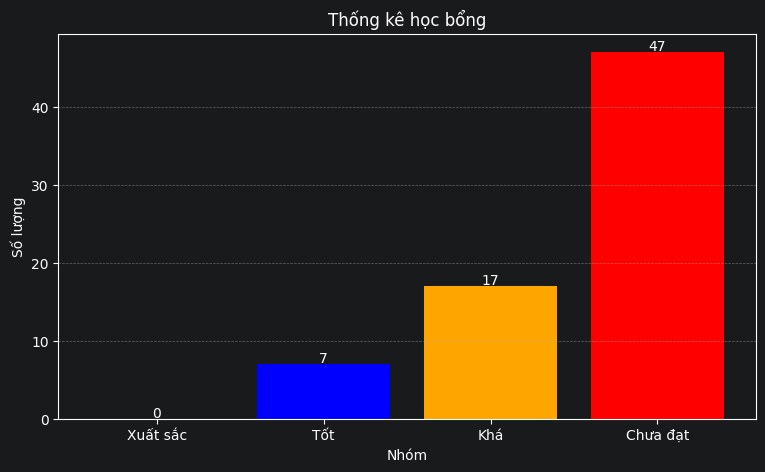

In [16]:
hien_thi_tieu_de(" Biểu đồ cột tỷ lệ sinh viên theo nhóm")
plt.figure(figsize=(9,5))

mau = ["green", "blue", "orange", "red"]

bars = plt.bar(
    thong_ke.index,
    thong_ke.values,
    color=mau
)

# Hiện số trên cột
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        int(bar.get_height()),
        ha='center'
    )

plt.title("Thống kê học bổng")
plt.xlabel("Nhóm")
plt.ylabel("Số lượng")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Biểu đồ tròn số lượng sinh viên theo nhóm

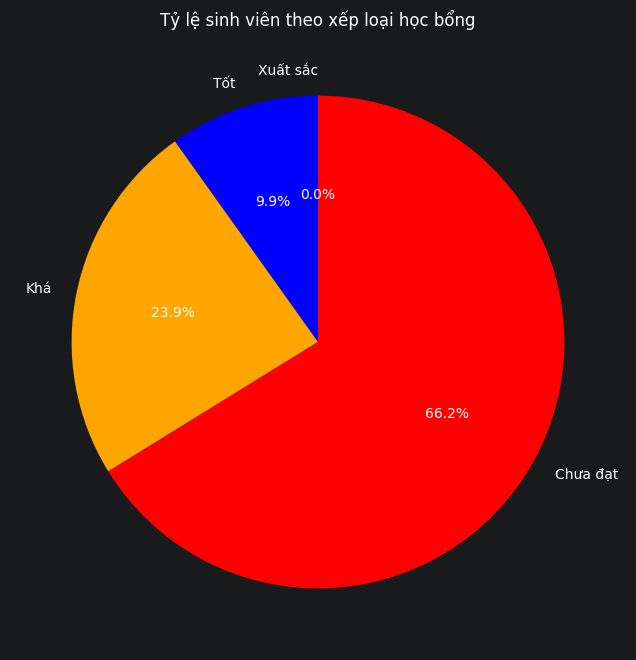

In [17]:
hien_thi_tieu_de(" Biểu đồ tròn tỷ lệ sinh viên theo nhóm")

plt.figure(figsize=(8,8))

colors = ["green", "blue", "orange", "red"]

plt.pie(
    thong_ke.values,
    labels=thong_ke.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Tỷ lệ sinh viên theo xếp loại học bổng")

plt.show()

# Biểu đồ phân cụm kmeans

In [18]:
X = students[["Điểm TB", "Số môn có điểm"]].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
students["Cụm KMeans"] = kmeans.fit_predict(X_scaled)

thu_tu_cum = students.groupby("Cụm KMeans")["Điểm TB"].mean().sort_values(ascending=False).index

ten_cum = {
    thu_tu_cum[0]: "Xuất sắc",
    thu_tu_cum[1]: "Tốt",
    thu_tu_cum[2]: "Khá",
    thu_tu_cum[3]: "Chưa đạt"
}

students["Nhóm KMeans"] = students["Cụm KMeans"].map(ten_cum)

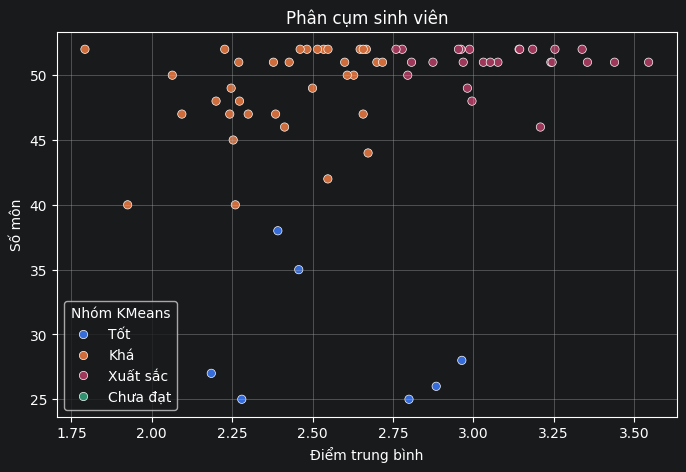

In [19]:
hien_thi_tieu_de("Biểu đồ phân cụm KMeans")

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=students,
    x="Điểm TB",
    y="Số môn có điểm",
    hue="Nhóm KMeans"
)

plt.xlabel("Điểm trung bình")
plt.ylabel("Số môn")
plt.title("Phân cụm sinh viên")

plt.grid(True)

plt.show()

# Xuất kết quả ra file Excel

In [33]:
hien_thi_tieu_de("18. Xuất kết quả ra file Excel")

output_file = "ket_qua_xet_hoc_bong_kmeans.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    result.to_excel(writer, sheet_name="Tong hop", index=False)

    for nhom in thu_tu_nhom:
        df_nhom = result[result["Xếp loại học bổng"] == nhom]
        df_nhom.to_excel(writer, sheet_name=nhom, index=False)

print("Đã xuất file:", output_file)

Đã xuất file: ket_qua_xet_hoc_bong_kmeans.xlsx
